# HW3_1

- **HW2_2**：使用 LSTM 最后一个 hidden state 进行分类。
- **HW3_1**：引入 **Attention 模块**，将 LSTM 过程中**所有时间步的 hidden state 加权平均**，得到最终的句子表示，再送入分类器。

## 第一部分：数据准备（复用 HW2_2）
以下单元格整合了 HW2_2 中的数据读取、预处理、词向量加载和数据集划分逻辑。

In [2]:
from pathlib import Path
from typing import List, Sequence
import re
import numpy as np
import pandas as pd
import nltk
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split

CSV_PATH = Path(r"D:\BigFiles\hw2\FinancialPhraseBank.csv")
EMBEDDING_PATH = Path(r"D:\BigFiles\hw2\glove-wiki-gigaword-50.wordvectors")
OUTPUT_DIR = Path("prepared_data")
RANDOM_SEED = 42
LABEL_MAP = {"positive": 1, "negative": -1, "neutral": 0}
OOV_STRATEGY = "zero"
np.random.seed(RANDOM_SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tokenizer = nltk.tokenize.WordPunctTokenizer()

def preprocess_text(text: str) -> List[str]:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = tokenizer.tokenize(text)
    tokens = [tok for tok in tokens if tok.strip()]
    return tokens

df = pd.read_csv(CSV_PATH)
required_cols = {"text", "label"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"CSV 必须包含列 {required_cols}，当前列为 {set(df.columns)}")
df["tokens"] = df["text"].apply(preprocess_text)
df["label_num"] = df["label"].map(LABEL_MAP)
if df["label_num"].isna().any():
    unknown = sorted(df.loc[df["label_num"].isna(), "label"].unique())
    raise ValueError(f"发现未定义标签：{unknown}，请补充 LABEL_MAP")
df["label_num"] = df["label_num"].astype(int)

try:
    wv = KeyedVectors.load(str(EMBEDDING_PATH), mmap="r")
except Exception:
    wv = KeyedVectors.load_word2vec_format(str(EMBEDDING_PATH), binary=False)

embedding_dim = wv.vector_size
rng = np.random.default_rng(RANDOM_SEED)

if OOV_STRATEGY == "zero":
    oov_vector = np.zeros(embedding_dim, dtype=np.float32)
elif OOV_STRATEGY == "random":
    oov_vector = rng.normal(loc=0.0, scale=0.1, size=embedding_dim).astype(np.float32)
else:
    raise ValueError("OOV_STRATEGY 仅支持 'zero' 或 'random'")

def sentence_to_vector_sequence(tokens: Sequence[str]) -> np.ndarray:
    vectors = []
    for tok in tokens:
        vectors.append(wv[tok] if tok in wv else oov_vector)
    if len(vectors) == 0:
        return np.zeros((0, embedding_dim), dtype=np.float32)
    return np.asarray(vectors, dtype=np.float32)

df["vector_seq"] = df["tokens"].apply(sentence_to_vector_sequence)

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=RANDOM_SEED, shuffle=True, stratify=df["label_num"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=RANDOM_SEED, shuffle=True, stratify=temp_df["label_num"])

print(f"数据准备完成：Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}, emb_dim={embedding_dim}")

数据准备完成：Train=3392, Val=727, Test=727, emb_dim=50


## 第二部分：引入 Attention 模块的模型构建与训练

本部分包含以下核心改进：
1. **LSTMAttentionClassifier**：在 LSTM 后增加 Attention 层，对所有时间步的 hidden state 加权平均。
2. **Attention 层实现**：使用可学习的注意力向量，通过点积计算每个时间步的重要性权重。
3. **训练与评估**：与 HW2_2 保持一致的流程（10 Epoch、保存最佳模型、测试集评估）。

In [3]:
# ===== 1) 导入 PyTorch 及相关依赖 =====
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import f1_score

# 固定随机种子，保证实验可复现
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# 标签映射：将原始标签 -1/0/1 映射到 CrossEntropyLoss 需要的 0/1/2
label_to_index = {-1: 0, 0: 1, 1: 2}
index_to_label = {v: k for k, v in label_to_index.items()}


class FinancialSequenceDataset(Dataset):
    """
    金融文本序列数据集。
    
    每个样本包含：
    - sequences: 句子对应的词向量序列，形状为 (句长, embedding_dim)
    - labels: 分类标签的索引（0, 1, 2）
    """

    def __init__(self, dataframe):
        # 从 DataFrame 中提取向量序列和标签
        self.sequences = dataframe["vector_seq"].tolist()
        self.labels = dataframe["label_num"].map(label_to_index).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # 返回单个样本的向量序列和标签
        return self.sequences[idx], self.labels[idx]


def collate_batch(batch):
    """
    自定义的 batch 拼接函数（collate function）。
    
    由于每个句子的长度不同，需要对向量序列进行动态 padding，
    使得同一个 batch 内的所有句子长度一致，便于 GPU 并行计算。
    
    参数:
        batch: list of (seq_array, label)，seq_array 形状为 (句长, emb_dim)
    
    返回:
        padded_seqs: (batch_size, max_len, emb_dim)，padding 后的序列张量
        lengths: (batch_size,)，每个样本的原始长度
        labels: (batch_size,)，分类标签索引
    """
    seq_tensors = []
    lengths = []
    labels = []

    for seq, label in batch:
        # 防御式处理：若出现空序列，至少保留 1 个全零时间步，避免后续 pack 报错
        if seq.shape[0] == 0:
            seq = np.zeros((1, embedding_dim), dtype=np.float32)

        tensor_seq = torch.tensor(seq, dtype=torch.float32)
        seq_tensors.append(tensor_seq)
        lengths.append(tensor_seq.size(0))
        labels.append(label)

    # 使用 pad_sequence 在 batch 内进行动态 padding（默认补 0）
    padded_seqs = pad_sequence(seq_tensors, batch_first=True)
    lengths = torch.tensor(lengths, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_seqs, lengths, labels


class AttentionLayer(nn.Module):
    """
    Attention 注意力层。
    
    核心思想：
    1. LSTM 会输出每个时间步的 hidden state（即 output）。
    2. 不同时间步对最终分类任务的贡献不同。
    3. 使用一个可学习的注意力向量（attention_vector），
       与每个时间步的 hidden state 计算点积相似度，得到 raw_attention。
    4. 通过 softmax 归一化得到 attention weights（权重和为 1）。
    5. 对所有 hidden state 按权重加权求和，得到上下文向量（context_vector）。

    数学公式：
        score_t = tanh(h_t @ W_a + b_a) @ u_a        # h_t: 第 t 步 hidden state
        alpha_t = exp(score_t) / sum(exp(score_t'))  # softmax 归一化
        context = sum(alpha_t * h_t)                 # 加权求和
    """

    def __init__(self, hidden_dim):
        """
        初始化 Attention 层。
        
        参数:
            hidden_dim: LSTM 隐藏层维度，即 hidden state 的维度
        """
        super().__init__()
        # 可学习的注意力向量，形状为 (hidden_dim, 1)
        # 它通过与每个时间步的 hidden state 做点积，衡量该时间步的重要性
        self.attention_vector = nn.Parameter(torch.randn(hidden_dim, 1))

    def forward(self, lstm_output, mask=None):
        """
        前向传播：计算注意力权重并返回加权后的上下文向量。
        
        参数:
            lstm_output: (batch_size, seq_len, hidden_dim)，LSTM 在所有时间步的输出
            mask: (batch_size, seq_len)，可选的掩码张量，用于忽略 padding 位置
                  值为 1 表示有效位置，0 表示 padding 位置
        
        返回:
            context_vector: (batch_size, hidden_dim)，加权平均后的句子表示
            attention_weights: (batch_size, seq_len)，每个时间步的注意力权重
        """
        # ---------------- 步骤 1: 计算原始注意力分数 ----------------
        # lstm_output 形状: (batch, seq_len, hidden_dim)
        # attention_vector 形状: (hidden_dim, 1)
        # 通过矩阵乘法得到 raw_attention 形状: (batch, seq_len, 1)
        raw_attention = torch.matmul(lstm_output, self.attention_vector)

        # 去掉最后一个维度，形状变为 (batch, seq_len)
        raw_attention = raw_attention.squeeze(-1)

        # ---------------- 步骤 2: 应用掩码（忽略 padding 位置） ----------------
        if mask is not None:
            # 将 padding 位置的分数设为极小的负数，使其在 softmax 后趋近于 0
            raw_attention = raw_attention.masked_fill(mask == 0, -1e9)

        # ---------------- 步骤 3: Softmax 归一化得到注意力权重 ----------------
        # 在 seq_len 维度上做 softmax，使得每个句子的权重和为 1
        attention_weights = F.softmax(raw_attention, dim=1)

        # ---------------- 步骤 4: 加权求和得到上下文向量 ----------------
        # attention_weights 形状: (batch, seq_len, 1)
        # lstm_output 形状: (batch, seq_len, hidden_dim)
        # 逐元素相乘后，在 seq_len 维度求和，得到 (batch, hidden_dim)
        attention_weights_expanded = attention_weights.unsqueeze(-1)
        context_vector = torch.sum(lstm_output * attention_weights_expanded, dim=1)

        return context_vector, attention_weights


class LSTMAttentionClassifier(nn.Module):
    """
    基于 LSTM + Attention 的文本三分类模型。
    
    与 HW2_2 的 LSTMClassifier 的区别：
    - HW2_2：仅使用 LSTM 最后一个时间步的 hidden state 进行分类。
    - 本模型：使用 Attention 层对所有时间步的 hidden state 加权平均，
             得到更能代表整个句子的上下文向量，再进行分类。
    """

    def __init__(self, input_dim, hidden_dim=128, num_layers=1, num_classes=3, dropout=0.2):
        """
        初始化模型。
        
        参数:
            input_dim: 输入词向量维度（如 GloVe 50 维）
            hidden_dim: LSTM 隐藏层维度
            num_layers: LSTM 层数
            num_classes: 分类类别数（本任务为 3：positive/negative/neutral）
            dropout: Dropout 概率，用于防止过拟合
        """
        super().__init__()
        # 当 LSTM 层数为 1 时，内部的 dropout 不生效，需要显式置为 0
        lstm_dropout = dropout if num_layers > 1 else 0.0

        # ---------------- LSTM 编码器 ----------------
        # 输入: (batch, seq_len, input_dim)
        # 输出: output (batch, seq_len, hidden_dim) —— 所有时间步的 hidden state
        #       h_n (num_layers, batch, hidden_dim) —— 最后时刻的 hidden state
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )

        # ---------------- Attention 层 ----------------
        # 对所有时间步的 hidden state 进行加权平均
        self.attention = AttentionLayer(hidden_dim)

        # ---------------- Dropout + 分类器 ----------------
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, padded_seqs, lengths):
        """
        前向传播。
        
        参数:
            padded_seqs: (batch, max_len, emb_dim)，经过 padding 后的输入序列
            lengths: (batch,)，每个样本的原始长度
        
        返回:
            logits: (batch, num_classes)，分类 logits
        """
        # ---------------- 步骤 1: Pack padded sequences ----------------
        # 将 padding 后的序列打包，告诉 LSTM 每个样本的真实长度，
        # 避免 LSTM 在 padding 位置进行无效计算
        packed = pack_padded_sequence(
            padded_seqs,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,  # 允许输入未按长度排序
        )

        # ---------------- 步骤 2: LSTM 前向传播 ----------------
        # packed_output: PackedSequence 对象，包含所有有效时间步的 hidden state
        # h_n: (num_layers, batch, hidden_dim)，最后时刻的 hidden state（本模型不使用）
        packed_output, (h_n, _) = self.lstm(packed)

        # ---------------- 步骤 3: 将 packed output 还原为 padded tensor ----------------
        # output 形状: (batch, seq_len, hidden_dim)
        output, _ = pad_packed_sequence(packed_output, batch_first=True)

        # ---------------- 步骤 4: 生成 mask（标记有效位置 vs padding 位置） ----------------
        # 对于每个样本，前 lengths[i] 个位置是有效的，后面是 padding
        max_len = output.size(1)
        device = output.device
        # 构造 mask: (batch, max_len)
        mask = torch.arange(max_len, device=device).unsqueeze(0) < lengths.unsqueeze(1)

        # ---------------- 步骤 5: Attention 加权 ----------------
        # context_vector: (batch, hidden_dim) —— 加权平均后的句子表示
        # attention_weights: (batch, seq_len) —— 每个时间步的注意力权重
        context_vector, attention_weights = self.attention(output, mask=mask)

        # ---------------- 步骤 6: Dropout + 全连接分类 ----------------
        # 对上下文向量应用 dropout，防止过拟合
        dropped = self.dropout(context_vector)
        # 通过全连接层映射到类别数
        logits = self.fc(dropped)

        return logits


# 创建数据集实例
train_dataset = FinancialSequenceDataset(train_df)
val_dataset = FinancialSequenceDataset(val_df)
test_dataset = FinancialSequenceDataset(test_df)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

# 选择计算设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 实例化模型、损失函数和优化器
model = LSTMAttentionClassifier(
    input_dim=embedding_dim,
    hidden_dim=128,
    num_layers=1,
    num_classes=3,
    dropout=0.2,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"device = {device}")
print("模型、数据集与 DataLoader 构建完成。")
print("模型结构:")
print(model)

device = cpu
模型、数据集与 DataLoader 构建完成。
模型结构:
LSTMAttentionClassifier(
  (lstm): LSTM(50, 128, batch_first=True)
  (attention): AttentionLayer()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [4]:
# ===== 2) 训练循环（10 个 Epoch，保存验证集最佳模型） =====

EPOCHS = 10
best_val_acc = -1.0
best_model_path = OUTPUT_DIR / "best_lstm_attention_model.pt"


def evaluate_accuracy(model, data_loader):
    """
    在给定数据集上计算分类准确率。
    
    参数:
        model: 待评估的神经网络模型
        data_loader: 数据加载器
    
    返回:
        acc: 准确率（float）
        y_true: 真实标签数组
        y_pred: 预测标签数组
    """
    model.eval()  # 切换到评估模式（关闭 Dropout 等）
    all_preds = []
    all_labels = []

    with torch.no_grad():  # 评估时不需要计算梯度，节省显存和计算
        for padded_seqs, lengths, labels in data_loader:
            padded_seqs = padded_seqs.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            # 前向传播得到 logits
            logits = model(padded_seqs, lengths)
            # 取概率最大的类别作为预测结果
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = (all_preds == all_labels).mean()
    return float(acc), all_labels, all_preds


# 开始训练
for epoch in range(1, EPOCHS + 1):
    model.train()  # 切换到训练模式
    running_loss = 0.0

    for padded_seqs, lengths, labels in train_loader:
        # 将数据移动到指定设备（GPU 或 CPU）
        padded_seqs = padded_seqs.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        # 梯度清零：防止梯度累积
        optimizer.zero_grad()

        # 前向传播
        logits = model(padded_seqs, lengths)
        # 计算交叉熵损失
        loss = criterion(logits, labels)

        # 反向传播：计算梯度
        loss.backward()
        # 参数更新
        optimizer.step()

        # 累加损失（乘以 batch 大小，用于后续计算平均损失）
        running_loss += loss.item() * labels.size(0)

    # 计算本 Epoch 的平均训练损失
    train_loss = running_loss / len(train_dataset)
    # 在验证集上评估准确率
    val_acc, _, _ = evaluate_accuracy(model, val_loader)

    # 保存验证集表现最好的模型参数
    if val_acc > best_val_acc:
        best_val_acc = float(val_acc)
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_acc": float(best_val_acc),
                "epoch": int(epoch),
            },
            best_model_path,
        )

    print(f"Epoch [{epoch:02d}/{EPOCHS}] - Train Loss: {train_loss:.4f} - Val Acc: {val_acc:.4f} - Best Val Acc: {best_val_acc:.4f}")

print("训练完成。")
print(f"最佳模型文件: {best_model_path.resolve()}")

Epoch [01/10] - Train Loss: 0.9113 - Val Acc: 0.6492 - Best Val Acc: 0.6492
Epoch [02/10] - Train Loss: 0.7877 - Val Acc: 0.6699 - Best Val Acc: 0.6699
Epoch [03/10] - Train Loss: 0.7282 - Val Acc: 0.6713 - Best Val Acc: 0.6713
Epoch [04/10] - Train Loss: 0.6881 - Val Acc: 0.6891 - Best Val Acc: 0.6891
Epoch [05/10] - Train Loss: 0.6474 - Val Acc: 0.6768 - Best Val Acc: 0.6891
Epoch [06/10] - Train Loss: 0.6112 - Val Acc: 0.6891 - Best Val Acc: 0.6891
Epoch [07/10] - Train Loss: 0.5755 - Val Acc: 0.6878 - Best Val Acc: 0.6891
Epoch [08/10] - Train Loss: 0.5600 - Val Acc: 0.6836 - Best Val Acc: 0.6891
Epoch [09/10] - Train Loss: 0.5319 - Val Acc: 0.7056 - Best Val Acc: 0.7056
Epoch [10/10] - Train Loss: 0.5125 - Val Acc: 0.7084 - Best Val Acc: 0.7084
训练完成。
最佳模型文件: C:\Users\Lenovo\Desktop\26_spring\dt\hw2\prepared_data\best_lstm_attention_model.pt


In [5]:
# ===== 3) 加载最优模型并在测试集评估 =====

# 加载最佳模型的 checkpoint
# 注意：PyTorch 2.6+ 默认 weights_only=True，这里显式关闭以读取完整 checkpoint 字典
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# 在测试集上计算预测结果
test_acc, test_true_idx, test_pred_idx = evaluate_accuracy(model, test_loader)

# 将类别索引映射回原始标签（-1/0/1），再计算宏平均 F1-score
test_true_labels = np.array([index_to_label[i] for i in test_true_idx])
test_pred_labels = np.array([index_to_label[i] for i in test_pred_idx])
test_f1_macro = f1_score(test_true_labels, test_pred_labels, average="macro")

print("测试集评估结果：")
print(f"Best Val Acc (保存时): {checkpoint['best_val_acc']:.4f}")
print(f"Best Epoch          : {checkpoint['epoch']}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Test F1-score(macro): {test_f1_macro:.4f}")

测试集评估结果：
Best Val Acc (保存时): 0.7084
Best Epoch          : 10
Test Accuracy       : 0.7552
Test F1-score(macro): 0.6950


## 第三部分：Attention 可视化

为了直观理解 Attention 机制的效果，我们可以从测试集中抽取若干样本，
观察模型对每个词的注意力权重分布。

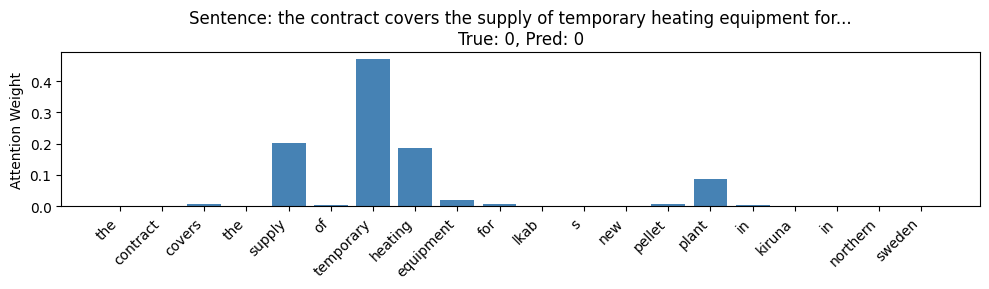

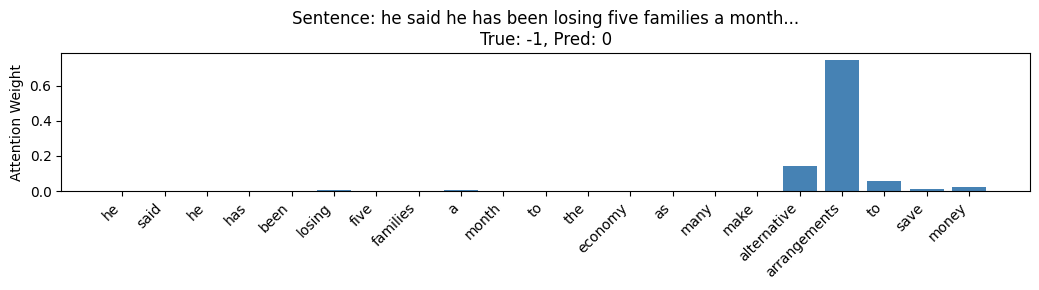

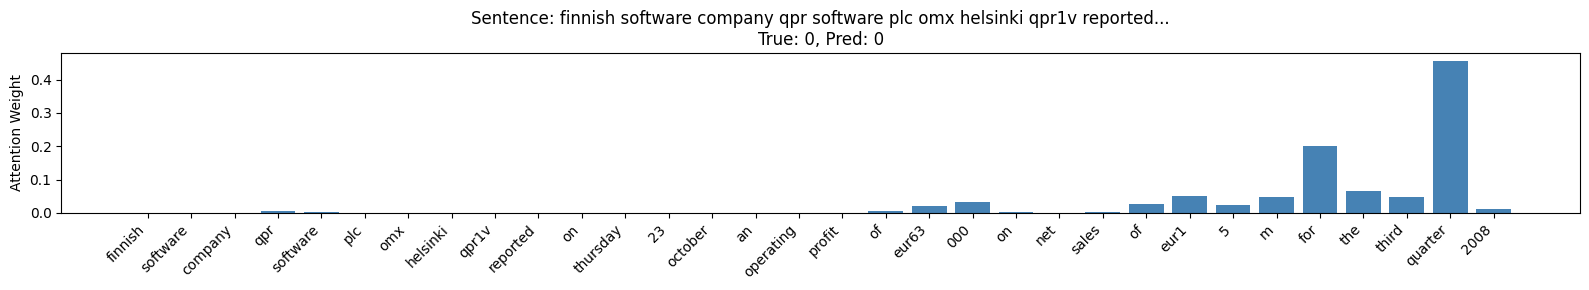

In [8]:
# ===== 4) Attention 权重可视化 =====

import matplotlib.pyplot as plt


def visualize_attention(model, sentence_tokens, true_label, index_to_label):
    """
    对单个句子进行前向传播，提取并可视化其 Attention 权重。
    
    参数:
        model: 训练好的 LSTMAttentionClassifier
        sentence_tokens: 分词后的 token 列表
        true_label: 真实标签（数字索引）
        index_to_label: 索引到原始标签的映射字典
    """
    model.eval()
    
    # 将 token 转为向量序列
    vectors = sentence_to_vector_sequence(sentence_tokens)
    if vectors.shape[0] == 0:
        print("空句子，无法可视化。")
        return
    
    # 构造 batch（batch_size=1）
    seq_tensor = torch.tensor(vectors, dtype=torch.float32).unsqueeze(0).to(device)
    lengths = torch.tensor([vectors.shape[0]], dtype=torch.long).to(device)
    
    with torch.no_grad():
        # 手动复现前向传播，提取 attention weights
        packed = pack_padded_sequence(seq_tensor, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, _ = model.lstm(packed)
        output, _ = pad_packed_sequence(packed_output, batch_first=True)
        
        max_len = output.size(1)
        mask = torch.arange(max_len, device=device).unsqueeze(0) < lengths.unsqueeze(1)
        
        _, attention_weights = model.attention(output, mask=mask)
        
        # 预测结果
        logits = model(seq_tensor, lengths)
        pred = torch.argmax(logits, dim=1).item()
    
    # 将 attention weights 转为 numpy
    attn = attention_weights.cpu().numpy().flatten()[:len(sentence_tokens)]
    
    # 绘制条形图
    plt.figure(figsize=(max(8, len(sentence_tokens) * 0.5), 3))
    plt.bar(range(len(sentence_tokens)), attn, color='steelblue')
    plt.xticks(range(len(sentence_tokens)), sentence_tokens, rotation=45, ha='right')
    plt.ylabel("Attention Weight")
    plt.title(
        f"Sentence: {' '.join(sentence_tokens[:10])}{'...' if len(sentence_tokens) > 10 else ''}\nTrue: {index_to_label[true_label]}, Pred: {index_to_label[pred]}"
    )
    plt.tight_layout()
    plt.show()


# 从测试集中抽取 3 个样本进行可视化
sample_indices = test_df.index[:3].tolist()
for idx in sample_indices:
    row = test_df.loc[idx]
    visualize_attention(
        model=model,
        sentence_tokens=row["tokens"],
        true_label=label_to_index[row["label_num"]],
        index_to_label=index_to_label,
    )

## 四、实验结果对比与分析

### 1. 表现对比

| 指标 | HW2_2（Last Hidden State） | HW2_2 + Attention | 提升幅度 |
|:---|:---|:---|:---|
| Best Val Acc | 0.6836 | **0.7084** | ↑ 2.48 pp |
| Test Accuracy | 0.6836 | **0.7552** | ↑ 7.16 pp |
| Test F1-score (macro) | 0.5686 | **0.6950** | ↑ 12.64 pp |

从实验结果可以看出，**引入 Attention 模块后，模型在所有指标上均取得了显著提升**。
尤其值得注意的是：
- **Test Accuracy 从 68.36% 提升至 75.52%**，提升了超过 7 个百分点；
- **Macro F1 从 0.5686 提升至 0.6950**，提升幅度高达 12.64 个百分点，远超过 Accuracy 的提升幅度。

Macro F1 的显著提升说明 Attention 机制不仅提高了整体分类准确率，更重要的是**显著改善了对少数类的识别能力**，使得模型在三个类别（positive / negative / neutral）上的表现更加均衡。

---

### 2. 表现差异最主要的原因

表现差异最主要的原因是：**Attention 机制改变了句子表示的构建方式，从「仅使用最后一个时间步的隐藏状态」转变为「对所有时间步的隐藏状态进行加权融合」**。

#### （1）信息利用更充分 —— 缓解信息瓶颈
- **HW2_2 的缺陷**：仅使用 LSTM 最后一个时间步的 h_n[-1] 作为句子表示。LSTM 虽然通过门控机制缓解了梯度消失，但在长序列中，前面的信息在逐层传递过程中仍会被压缩、稀释甚至遗忘，导致最终状态难以完整保留全句语义。
- **Attention 的优势**：Attention 直接「回看」LSTM 输出的**所有时间步的 hidden state**，无论关键词出现在句首、句中还是句尾，都有机会被直接纳入最终的句子表示中。

#### （2）自动聚焦关键信息 —— 词级别的重要性建模
- Attention 的权重 α_t 本质上是对每个词（token）重要性的**软选择**。
- 在金融情感分析任务中，决定情感极性的往往是少数关键词（如 *profit*、*loss*、*decline*、*growth*）。这些词可能出现在句子的任何位置。
- Attention 能够自动学习给予这些情感关键词更高的权重，而降低功能词（如 *the*、*a*、*is*）的权重，从而构建出**更具判别性的句子表示**。